In [14]:
import os

base = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection"
print("Contents of base directory:")
print(os.listdir(base))


Contents of base directory:
['sample_submission.csv', 'train.csv', 'test', 'train']


In [ ]:
#This block is designed so the user can convert MAX_FILES no. of images to png each time it is run, instead of converting all the files at once.
import os
import pydicom
import cv2
import numpy as np
from tqdm import tqdm

DICOM_DIR = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train"
OUTPUT_DIR = "/kaggle/working/images"
MAX_FILES = 1300 #edit this variable to change the no. of files processed each time

os.makedirs(OUTPUT_DIR, exist_ok=True)

def normalize_image(img):
    img = img.astype(np.float32)
    img -= img.min()
    img /= (img.max() + 1e-8)
    img *= 255.0
    return img.astype(np.uint8)

dicom_files = []

for root, _, files in os.walk(DICOM_DIR):
    for f in files:
        if f.lower().endswith((".dcm", ".dicom")):
            dicom_files.append(os.path.join(root, f))

print(f"Found {len(dicom_files)} DICOM files")

converted = set(os.listdir(OUTPUT_DIR))

for dicom_path in tqdm(dicom_files[len(converted):len(converted)+MAX_FILES]):
    filename = os.path.basename(dicom_path).replace(".dicom", ".png")

    if filename in converted:
        continue  # skip already converted files

    try:
        ds = pydicom.dcmread(dicom_path)
        image = normalize_image(ds.pixel_array)

        output_path = os.path.join(OUTPUT_DIR, filename)
        cv2.imwrite(output_path, image)

    except Exception as e:
        print(f"Failed: {dicom_path} | {e}")


print("DICOM → PNG conversion completed")


Found 15000 DICOM files


 15%|█▍        | 191/1300 [03:42<31:12,  1.69s/it]

(np.float64(-0.5), np.float64(2663.5), np.float64(3339.5), np.float64(-0.5))

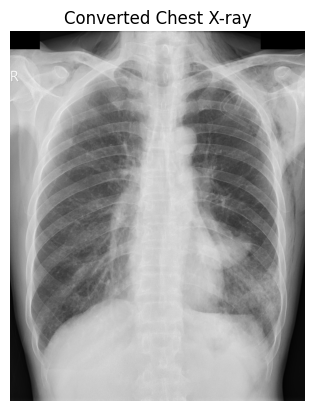

In [16]:
import cv2
import matplotlib.pyplot as plt
import os

img_file = os.listdir("/kaggle/working/images")[0]
img = cv2.imread(f"/kaggle/working/images/{img_file}", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Converted Chest X-ray")
plt.axis("off")


In [12]:
#Optional Code block that shows how many images have been converted
total_dicom = len(dicom_files)

converted_images = [
    f for f in os.listdir(OUTPUT_DIR)
    if f.lower().endswith(".png")
]

print("Total DICOM files:", total_dicom)
print("Converted PNG files:", len(converted_images))
print("Remaining:", total_dicom - len(converted_images))


Total DICOM files: 15000
Converted PNG files: 200
Remaining: 14800


In [4]:
import pandas as pd

csv_path = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()


Shape: (67914, 8)


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [5]:
#Column names
print(df.columns)

Index(['image_id', 'class_name', 'class_id', 'rad_id', 'x_min', 'y_min',
       'x_max', 'y_max'],
      dtype='object')


In [6]:
#This shows all abnormality types.
df["class_name"].unique()

array(['No finding', 'Cardiomegaly', 'Aortic enlargement',
       'Pleural thickening', 'ILD', 'Nodule/Mass', 'Pulmonary fibrosis',
       'Lung Opacity', 'Atelectasis', 'Other lesion', 'Infiltration',
       'Pleural effusion', 'Calcification', 'Consolidation',
       'Pneumothorax'], dtype=object)

In [7]:
#This shows how many unique images there are
df["image_id"].nunique()

15000

In [8]:
#This shows class distribution
class_counts = df["class_name"].value_counts()
print(class_counts)

class_name
No finding            31818
Aortic enlargement     7162
Cardiomegaly           5427
Pleural thickening     4842
Pulmonary fibrosis     4655
Nodule/Mass            2580
Lung Opacity           2483
Pleural effusion       2476
Other lesion           2203
Infiltration           1247
ILD                    1000
Calcification           960
Consolidation           556
Atelectasis             279
Pneumothorax            226
Name: count, dtype: int64


### Preprocessing Note

The VinBigData dataset uses the `.dicom` file extension for medical images.
The preprocessing pipeline was designed to handle both `.dcm` and `.dicom`
formats to ensure robust DICOM image conversion.



## Dataset Overview

**Dataset Name:** VinBigData Chest X-ray Abnormalities Detection  
**Source:** Kaggle / VinBigData  
**Data Types:**
- DICOM chest X-ray images
- CSV annotation files containing labels and bounding boxes

The dataset is mounted in `/kaggle/input/` as a read-only directory.
